# Delivery Delay Prediction — XGBoost
**Goals:**
- Predict delivery delay (`delayed` = 0/1)
- Recommend best delivery partner given available inputs
- SQL-friendly output (MySQL / SQLTools compatible)
- Power BI friendly exports
- Handles missing/partial feature inputs gracefully

**Dataset:** `final_logistics_dataset_with_dates_.xlsx` (50 columns)


## 1. Install dependencies

In [ ]:
!pip install xgboost scikit-learn pandas numpy sqlalchemy pymysql python-dotenv openpyxl --quiet
# TiDB Cloud requires SSL; cryptography is needed by PyMySQL for TLS
!pip install cryptography --quiet

## 2. Load data from Excel

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

CSV_PATH = '../data/Logistics_Delivery_Dataset_updated.csv'  # ← your path

df = pd.read_csv(CSV_PATH, index_col=False)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

Shape: (25000, 55)
Columns: ['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost', 'traffic_level', 'fuel_cost', 'delivery_priority', 'warehouse_location', 'driver_experience_years', 'customer_type', 'order_value', 'profit_margin', 'customer_satisfaction_score', 'carbon_emission_kg', 'late_delivery_penalty', 'return_requested', 'delivery_shift', 'operational_zone', 'source_city', 'destination_city', 'route_type', 'driver_age_group', 'driver_rating', 'accident_history_flag', 'road_quality_index', 'gps_route_deviation_km', 'number_of_stops', 'traffic_delay_minutes', 'warehouse_to_customer_distance', 'vehicle_capacity_utilization', 'rush_hour_delivery', 'weather_severity_score', 'driver_daily_deliveries', 'maintenance_score', 'weekend_delivery', 'holiday_season', 'net_profit', 'order

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,...,weekend_delivery,holiday_season,net_profit,order_date,pickup_date,delivery_date,order_year,order_month,order_day,order_quarter
0,100000,delhivery,automobile parts,bike,same day,Surat,clear,297.0,46.96,29.7,...,No,Yes,2699.33,2025-10-16 00:00:00,2025-10-16 04:00:00,2025-10-17 09:42:00,2025,October,Thursday,Q4
1,100001,xpressbees,cosmetics,ev van,express,Bhopal,cold,89.6,47.39,22.7,...,No,No,433.17,2024-01-26 00:00:00,2024-01-27 00:00:00,2024-01-27 22:42:00,2024,January,Friday,Q1
2,100002,shadowfax,groceries,truck,two day,Bhubaneswar,rainy,273.5,26.89,26.8,...,Yes,Yes,-3860.81,2024-10-08 00:00:00,2024-10-08 08:00:00,2024-10-09 10:48:00,2024,October,Tuesday,Q4


## 3. TiDB Cloud connection

In [3]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()  # reads .env from the current working directory

import ssl, platform

# Auto-detect CA bundle path by OS
_ca_paths = {
    "Linux":  "/etc/ssl/certs/ca-certificates.crt",
    "Darwin": "/etc/ssl/cert.pem",
    "Windows": "C:/Windows/System32/curl-ca-bundle.crt",
}

CA_CERT = os.getenv("TIDB_CA_CERT", _ca_paths.get(platform.system(), "/etc/ssl/certs/ca-certificates.crt"))

connect_args = {
    "ssl": {
        "ca": CA_CERT,
    }
}

from urllib.parse import quote_plus

engine = create_engine(
    f"mysql+pymysql://"
    f"{quote_plus(os.getenv('MYSQL_USER'))}:"
    f"{quote_plus(os.getenv('MYSQL_PASSWORD'))}@"
    f"{os.getenv('MYSQL_HOST')}:"
    f"{os.getenv('MYSQL_PORT', '4000')}/"
    f"{os.getenv('MYSQL_DB')}",
    connect_args=connect_args,
    pool_pre_ping=True,
    pool_recycle=1800,
)

with engine.connect() as conn:
    print("TiDB Cloud connected ✅")

TiDB Cloud connected ✅


In [4]:
df.to_sql(
    name='delivery_logistics',
    con=engine,
    if_exists='replace',
    index=False,
    chunksize=500,
    method='multi'
)
print(f'✅ Imported {len(df)} rows to TiDB: delivery_logistics')

✅ Imported 25000 rows to TiDB: delivery_logistics


## 4. Load data from TiDB Cloud (or fall back to Excel)

In [5]:
try:
    df = pd.read_sql("SELECT * FROM delivery_logistics", engine)
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
    print('Loaded from TiDB Cloud. Shape:', df.shape)
except Exception as e:
    print(f'TiDB read failed ({e}), using Excel instead.')
    df = pd.read_excel(EXCEL_PATH, engine='openpyxl')
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
    print('Using Excel data. Shape:', df.shape)

df.head(3)

Loaded from TiDB Cloud. Shape: (25000, 55)


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,...,weekend_delivery,holiday_season,net_profit,order_date,pickup_date,delivery_date,order_year,order_month,order_day,order_quarter
0,100000,delhivery,automobile parts,bike,same day,Surat,clear,297.0,46.96,29.7,...,No,Yes,2699.33,2025-10-16 00:00:00,2025-10-16 04:00:00,2025-10-17 09:42:00,2025,October,Thursday,Q4
1,100001,xpressbees,cosmetics,ev van,express,Bhopal,cold,89.6,47.39,22.7,...,No,No,433.17,2024-01-26 00:00:00,2024-01-27 00:00:00,2024-01-27 22:42:00,2024,January,Friday,Q1
2,100002,shadowfax,groceries,truck,two day,Bhubaneswar,rainy,273.5,26.89,26.8,...,Yes,Yes,-3860.81,2024-10-08 00:00:00,2024-10-08 08:00:00,2024-10-09 10:48:00,2024,October,Tuesday,Q4


## 5. Feature engineering & preprocessing

In [ ]:
# ── Derived feature: how much extra time vs expected ────────────────────────
# 

# ── Feature columns — PRE-DELIVERY ONLY ─────────────────────────────────────
CATEGORICAL = [
    'delivery_partner', 'package_type', 'vehicle_type',
    'delivery_mode', 'region', 'weather_condition',
    'traffic_level', 'delivery_priority', 'customer_type',
    'delivery_shift', 'operational_zone', 'route_type',
    'driver_age_group', 'return_requested', 'rush_hour_delivery',
    'weekend_delivery', 'holiday_season', 'accident_history_flag'
]

NUMERIC = [
   
    'distance_km', 'package_weight_kg',
    'expected_time_hours', 'delivery_cost', 'fuel_cost',
    'driver_experience_years', 'road_quality_index',
    'number_of_stops', 'warehouse_to_customer_distance',
    'vehicle_capacity_utilization', 'weather_severity_score',
    'driver_daily_deliveries', 'maintenance_score', 'driver_rating',

   
    'gps_route_deviation_km', 'traffic_delay_minutes',


]

# Keep only columns that exist in the dataframe
CATEGORICAL  = [c for c in CATEGORICAL if c in df.columns]
NUMERIC      = [c for c in NUMERIC     if c in df.columns]
ALL_FEATURES = CATEGORICAL + NUMERIC

print('Categorical features:', CATEGORICAL)
print('Numeric features:', NUMERIC)
print('\nTarget distribution:')
print(df['delayed_flag'].value_counts())

Categorical features: ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'traffic_level', 'delivery_priority', 'customer_type', 'delivery_shift', 'operational_zone', 'route_type', 'driver_age_group', 'return_requested', 'rush_hour_delivery', 'weekend_delivery', 'holiday_season', 'accident_history_flag']
Numeric features: ['distance_km', 'package_weight_kg', 'expected_time_hours', 'delivery_cost', 'fuel_cost', 'driver_experience_years', 'road_quality_index', 'number_of_stops', 'warehouse_to_customer_distance', 'vehicle_capacity_utilization', 'weather_severity_score', 'driver_daily_deliveries', 'maintenance_score', 'driver_rating', 'gps_route_deviation_km', 'traffic_delay_minutes']

Target distribution:
delayed_flag
0    18331
1     6669
Name: count, dtype: int64


## 6. Build a pipeline that handles missing features

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

# Categorical: impute with 'Unknown', then encode as integers
cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Numeric: impute with median
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, CATEGORICAL),
    ('num', num_pipeline, NUMERIC)
])

model = Pipeline([
    ('prep', preprocessor),
    ('clf',  XGBClassifier(
                n_estimators=200,
                max_depth=5,
                learning_rate=0.1,
                eval_metric='logloss',
                random_state=42
    ))
])

print('Pipeline ready.')

Pipeline ready.


## 7. Train / Test split & evaluation

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

X = df[ALL_FEATURES]
y = df['delayed_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

y_pred  = model.predict(X_test)
y_prob  = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      3666
           1       0.86      0.87      0.86      1334

    accuracy                           0.93      5000
   macro avg       0.90      0.91      0.91      5000
weighted avg       0.93      0.93      0.93      5000

ROC-AUC: 0.9796


## 8. Feature importance

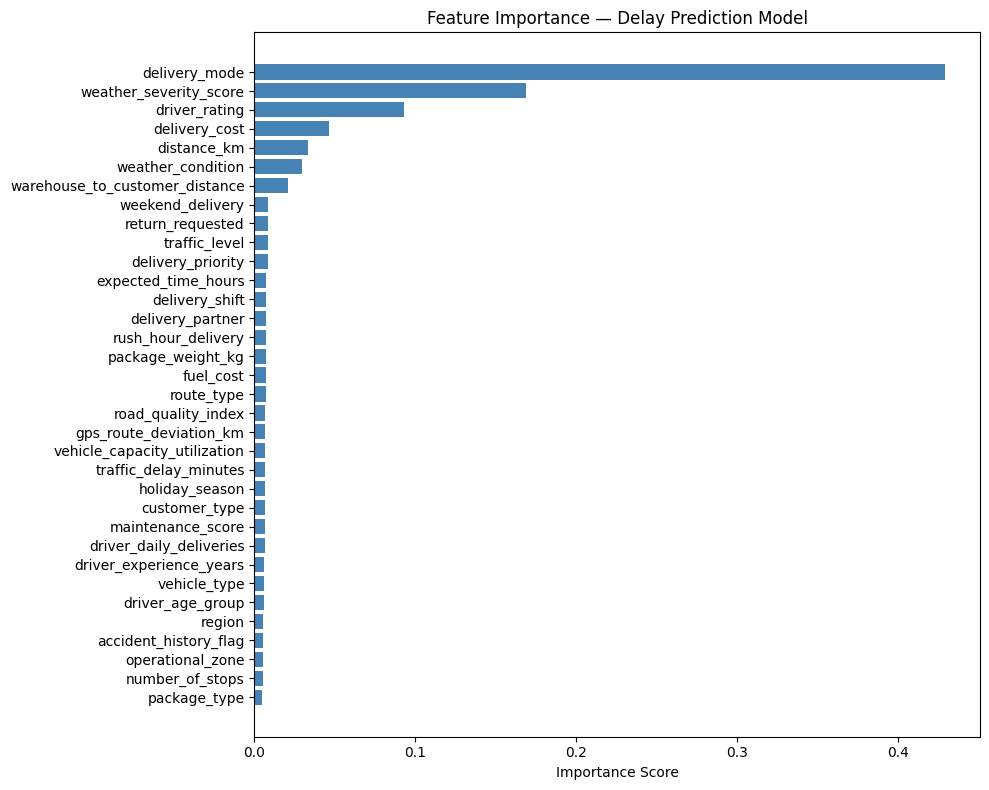

In [12]:
import matplotlib.pyplot as plt

feat_names = CATEGORICAL + NUMERIC
importances = model.named_steps['clf'].feature_importances_

fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(fi_df['feature'], fi_df['importance'], color='steelblue')
ax.set_title('Feature Importance — Delay Prediction Model')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 9. Best partner recommender (partial input supported)

In [16]:
PARTNERS = df['delivery_partner'].dropna().unique().tolist()

def recommend_partner(user_input: dict, top_n: int = 3) -> pd.DataFrame:
    """
    Given a dict of known features (any subset), returns the top_n partners
    ranked by lowest predicted delay probability.
    Missing features are left as NaN — the imputers handle them.
    """
    rows = []
    for partner in PARTNERS:
        row = {col: np.nan for col in ALL_FEATURES}
        row.update(user_input)
        row['delivery_partner'] = partner
        rows.append(row)

    input_df = pd.DataFrame(rows, columns=ALL_FEATURES)
    probs = model.predict_proba(input_df)[:, 1]

    result = pd.DataFrame({
        'delivery_partner': PARTNERS,
        'delay_probability': probs
    }).sort_values('delay_probability').head(top_n).reset_index(drop=True)

    result['rank'] = result.index + 1
    return result


# ── Demos ───────────────────────────────────────────────────────────────────
print('Top partners for a rainy north region shipment:')
print(recommend_partner({'region': 'North Zone', 'distance_km': 200, 'weather_condition': 'rainy'}))

print('\nTop partners with traffic & priority:')
print(recommend_partner({
    'region': 'South Zone',
    'distance_km': 350,
    'weather_condition': 'stormy',
    'traffic_level': 'High',
    'delivery_priority': 'Critical'
}))

Top partners for a rainy north region shipment:
  delivery_partner  delay_probability  rank
0        delhivery           0.978654     1
1              dhl           0.978654     2
2        blue dart           0.981164     3

Top partners with traffic & priority:
  delivery_partner  delay_probability  rank
0        delhivery           0.995811     1
1              dhl           0.995811     2
2        blue dart           0.996311     3


## 10. Score the full dataset & write predictions back to TiDB Cloud

In [14]:
# Score full dataset
df['predicted_delay_prob'] = model.predict_proba(df[ALL_FEATURES])[:, 1]
df['predicted_delayed']    = (df['predicted_delay_prob'] >= 0.5).astype(int)

# Columns to export — clean for SQL / Power BI
EXPORT_COLS = [
    'delivery_id', 'delivery_partner', 'package_type', 'vehicle_type',
    'delivery_mode', 'region', 'weather_condition', 'traffic_level',
    'delivery_priority', 'delivery_shift', 'route_type',
    'distance_km', 'package_weight_kg', 'delivery_cost', 'fuel_cost',
    'driver_experience_years', 'driver_rating', 'traffic_delay_minutes',
    'weather_severity_score', 'road_quality_index',
    'delayed_flag', 'predicted_delayed', 'predicted_delay_prob',
    'order_date', 'pickup_date'
]

# Keep only columns that exist
EXPORT_COLS = [c for c in EXPORT_COLS if c in df.columns]
output_df = df[EXPORT_COLS].copy()
output_df['predicted_delay_prob'] = output_df['predicted_delay_prob'].round(4)

print(output_df.head(3))
print('\nShape:', output_df.shape)

   delivery_id delivery_partner      package_type vehicle_type delivery_mode  \
0       100000        delhivery  automobile parts         bike      same day   
1       100001       xpressbees         cosmetics       ev van       express   
2       100002        shadowfax         groceries        truck       two day   

        region weather_condition traffic_level delivery_priority  \
0        Surat             clear          High          Critical   
1       Bhopal              cold          High            Medium   
2  Bhubaneswar             rainy        Medium          Critical   

  delivery_shift  ... driver_experience_years  driver_rating  \
0        Evening  ...                       8            4.0   
1      Afternoon  ...                       1            4.2   
2      Afternoon  ...                       1            4.0   

   traffic_delay_minutes  weather_severity_score  road_quality_index  \
0                     42                       1                  80   
1    

In [15]:
# ── Option A: Save to CSV (ready for Power BI import) ───────────────────────
output_df.to_csv('delay_predictions_output.csv', index=False)
print('Saved → predictions_output.csv')

# ── Option B: Write predictions to TiDB Cloud ───────────────────────────────
output_df.to_sql(
    name='delivery_predictions',
    con=engine,
    if_exists='replace',    # change to 'append' to keep old rows
    index=False,
    chunksize=500,
    method='multi',
)
print('Written to TiDB Cloud table: delivery_predictions ✅')

Saved → predictions_output.csv
Written to TiDB Cloud table: delivery_predictions ✅


## 11. MySQL-friendly SQL views

Once the `delivery_predictions` table exists in TiDB Cloud, run these queries in SQLTools:

```sql
-- Delay rate per partner
SELECT
    delivery_partner,
    COUNT(*)                                          AS total_deliveries,
    SUM(predicted_delayed)                            AS predicted_delays,
    ROUND(AVG(predicted_delay_prob) * 100, 2)         AS avg_delay_prob_pct
FROM delivery_predictions
GROUP BY delivery_partner
ORDER BY avg_delay_prob_pct;

-- High-risk deliveries (prob > 0.7)
SELECT *
FROM delivery_predictions
WHERE predicted_delay_prob > 0.70
ORDER BY predicted_delay_prob DESC;

-- Delay risk by traffic level & weather
SELECT
    traffic_level,
    weather_condition,
    ROUND(AVG(predicted_delay_prob) * 100, 2) AS avg_delay_pct,
    COUNT(*) AS total
FROM delivery_predictions
GROUP BY traffic_level, weather_condition
ORDER BY avg_delay_pct DESC;

-- Delay risk by delivery priority and route type
SELECT
    delivery_priority,
    route_type,
    ROUND(AVG(predicted_delay_prob) * 100, 2) AS avg_delay_pct
FROM delivery_predictions
GROUP BY delivery_priority, route_type
ORDER BY avg_delay_pct DESC;
```

## 12. Save the trained model (optional)

In [ ]:
import joblib

joblib.dump(model, 'delay_model.pkl')
print('Model saved → delay_model.pkl')

# To reload:
# model = joblib.load('delay_model.pkl')

## 13. Quick re-use demo — predict a single shipment

In [17]:
new_shipment = {
    'region':            'South Zone',
    'distance_km':       350,
    'vehicle_type':      'truck',
    'weather_condition': 'stormy',
    'traffic_level':     'High',
    'delivery_priority': 'Critical',
    'driver_experience_years': 3
}

recommendations = recommend_partner(new_shipment, top_n=3)
print('Best partners for this shipment:')
print(recommendations)

Best partners for this shipment:
  delivery_partner  delay_probability  rank
0        delhivery           0.996231     1
1              dhl           0.996231     2
2        blue dart           0.996682     3


In [18]:
# Predict delay for a specific shipment row
sample = pd.DataFrame([{
    'delivery_partner': 'delhivery',
    'package_type': 'electronics',
    'vehicle_type': 'ev van',
    'delivery_mode': 'express',
    'region': 'West Zone',
    'weather_condition': 'rainy',
    'traffic_level': 'High',
    'delivery_priority': 'Critical',
    'distance_km': 150,
    'package_weight_kg': 5.0,
    'delivery_time_hours': 20,
    'expected_time_hours': 15,
    'time_overrun': 5,
    'delivery_cost': 900,
    'fuel_cost': 400,
    'driver_experience_years': 2,
    'road_quality_index': 75,
    'traffic_delay_minutes': 45,
    'weather_severity_score': 4
}])

# Fill any missing required columns with NaN
for col in ALL_FEATURES:
    if col not in sample.columns:
        sample[col] = np.nan
sample = sample[ALL_FEATURES]

prediction   = model.predict(sample)[0]
probability  = model.predict_proba(sample)[0][1]

if prediction == 1:
    print("⚠️  Delivery likely DELAYED")
else:
    print("✅  Delivery likely ON TIME")
print(f"Delay Probability: {probability:.2%}")

⚠️  Delivery likely DELAYED
Delay Probability: 98.40%


## 14. Verify predictions in TiDB Cloud

In [19]:
df_sql = pd.read_sql(
    "SELECT * FROM delivery_predictions LIMIT 10;",
    engine
)
print(df_sql.head())

   delivery_id delivery_partner      package_type vehicle_type delivery_mode  \
0       100000        delhivery  automobile parts         bike      same day   
1       100001       xpressbees         cosmetics       ev van       express   
2       100002        shadowfax         groceries        truck       two day   
3       100003              dhl       electronics       ev van      same day   
4       100004              dhl          clothing          van       two day   

        region weather_condition traffic_level delivery_priority  \
0        Surat             clear          High          Critical   
1       Bhopal              cold          High            Medium   
2  Bhubaneswar             rainy        Medium          Critical   
3        Patna              cold           Low            Medium   
4      Lucknow             foggy        Medium              High   

  delivery_shift  ... driver_experience_years  driver_rating  \
0        Evening  ...                       8 